In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from datetime import datetime
from rapidfuzz import fuzz
import numpy as np
from scipy.spatial.distance import pdist,squareform
from requests import post

In [4]:
license_data = pd.read_excel('../raw_data.xlsx', engine='openpyxl')
license_data['Start date'] = pd.to_datetime(license_data['Start date'], format='%m/%d/%Y')
license_data['Close date'] = pd.to_datetime(license_data['Close date'], format='%m/%d/%Y')

license_data = license_data[~ license_data['Start date'].isna()] # Remove all entries without a start date
license_data = license_data[license_data['Start date']  < pd.to_datetime(datetime.today())] # Only look at businesses who have already opened

license_data = license_data[license_data['Bus City, State'].fillna("").map(lambda x: fuzz.ratio('SAN LUIS OBISPO', x.upper())) > 50] # Only look at businesses in the city of slo

license_data = license_data[~ license_data['Bus address'].isna()] # Must have a bus address listed

license_data = license_data.drop(['Owner Name 1', 'Account #'],axis=1)

In [5]:
type_mappings = {
    "Downtown Association" : "Downtown Association",
    "Residential Rental" : "Rental",
    "Commercial Rental Property" : "Rental",
    "General Service" : "Service",
    "Professional Service" :"Service",
    "General Retailer" : "Retail",
    "Contractor" : "Service",
    "Massage Therapist" : "Service",
    "General Manufacturer" : "Other",
    "General Wholesaler" : "Other",
    "Homestay Temporary TOT" : "Hotel",
    "Utilities/Transportation" : "Other",
    "Cannabis Permit Fee" : "Retail",
    "General Gun Dealer" : "Retail",
    "Cannabis Delivery Driver" : "Service"
}


license_data['type'] = license_data['Rate type (STD)'].map(type_mappings)

del type_mappings
license_data

,DBA,Business type,Bus address,"Bus City, State",Start date,Close date,License description,Rate type (STD),type
0,!ROMP,Apparel/Accessories,714 HIGUERA ST,"SAN LUIS OBISPO, CA 93401-3513",2005-04-06,2019-05-03,NaN,Downtown Association,Downtown Association
1,"""""""Angel Lynn""""""",Misc Business Services,3860 S HIGUERA ST SP A24,"SAN LUIS OBISPO, CA 93401-7460",2009-06-08,2012-01-01,"Face Painting, Balloon Sculpture, Card Tricks,...",General Service,Service
2,"""""""Slack""""""",Rental- Residential,2045 SLACK ST,"SAN LUIS OBISPO, CA 93405-2107",2009-10-28,2017-04-20,Residential Property Rental,Residential Rental,Rental
4,@ BITES,Restaurant,195 N SANTA ROSA ST,"SAN LUIS OBISPO, CA 93405-1322",2021-04-05,NaT,Fast Food Restaurant,General Retailer,Retail
5,@ Nails,Beauty Salon,1519 FROOM RANCH WAY STE A BLDG E,"SAN LUIS OBISPO, CA 93405-7211",2008-01-23,NaT,Nail Salon,General Service,Service
...,...,...,...,...,...,...,...,...,...
23759,Zoric Logistics LLC,Home Occupation,994 BLUEBELL WAY,"SAN LUIS OBISPO, CA 93401-7653",2021-10-06,2025-08-11,Transportation & Delivery of Goods,General Service,Service
23760,Zs Unlimited,Auto Mechanic/Detailer/Services,3621 SACRAMENTO DR 6,"SAN LUIS OBISPO, CA 93401-7169",1993-06-25,2007-11-27,NaN,General Service,Service
23761,Zube's Import Auto Sales,Retail,225 TANK FARM RD STE B2,"SAN LUIS OBISPO, CA 93401-7501",2009-10-28,NaT,Retail Used Auto Sales - Max Of 5 Cars Display...,General Retailer,Retail
23763,Zumer Products Llc,"Wholesale, Distributors",3563 SUELDO ST Q,"SAN LUIS OBISPO, CA 93401-7332",2000-08-10,2009-10-21,NaN,General Wholesaler,Other


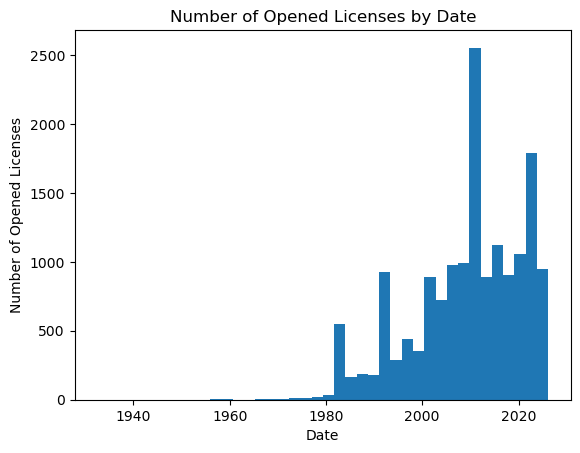

count                            16026
mean     2009-04-02 07:55:19.655559680
min                1932-07-01 00:00:00
25%                2002-06-07 00:00:00
50%                2010-09-15 00:00:00
75%                2018-07-30 00:00:00
max                2026-03-06 00:00:00
Name: Start date, dtype: object


In [6]:
license_data['Start date'].hist(
    bins=40,
)
plt.title("Number of Opened Licenses by Date")
plt.grid(False)
plt.xlabel("Date")
plt.ylabel("Number of Opened Licenses")
plt.show()
print(license_data['Start date'].describe())

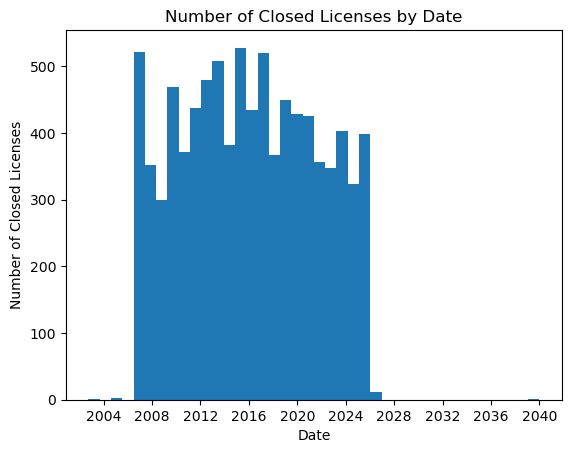

count                             8816
mean     2016-01-08 17:51:00.980036352
min                2002-09-30 00:00:00
25%                2011-06-30 00:00:00
50%                2015-12-02 12:00:00
75%                2020-06-30 00:00:00
max                2040-01-01 00:00:00
Name: Close date, dtype: object


In [7]:
license_data['Close date'].hist(
    bins=40,
)
plt.title("Number of Closed Licenses by Date")
plt.grid(False)
plt.xlabel("Date")
plt.ylabel("Number of Closed Licenses")
plt.show()
print(license_data['Close date'].describe())


In [8]:
close_times = pd.to_timedelta(pd.to_datetime(license_data['Close date'], format='%m/%d/%Y') - pd.to_datetime(license_data['Start date'], format='%m/%d/%Y'), unit='D').combine(pd.to_datetime(datetime.now()) -  pd.to_datetime(license_data['Start date']),
                  lambda d1,d2: d2 if d1 is None else d2).dt.days

close_times.name = 'closure_time'

censor = (~ license_data['Close date'].isna()).astype(int)

out_frame = close_times.to_frame()

out_frame['censor'] = censor

del close_times
del censor

out_frame

,closure_time,censor
0,7639,1
1,6115,1
2,5973,1
4,1796,0
5,6617,0
...,...,...
23759,1612,1
23760,11942,1
23761,5973,0
23763,9339,1


<Axes: title={'center': 'Number of Months until Business Closure'}, xlabel='Months', ylabel='Count'>

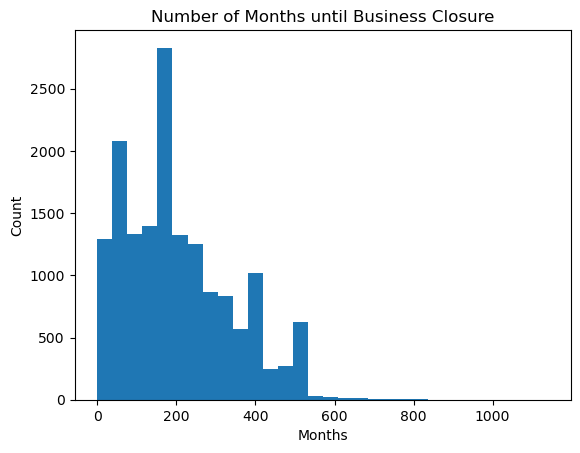

In [9]:
(out_frame['closure_time'] / 30).plot.hist(
    bins=30,
    xlabel='Months',
    ylabel='Count',
    title='Number of Months until Business Closure'
)

# Adding Longitude and Latitude

In [8]:

addr = license_data['Bus address'].to_frame()
addr['City'] = 'San Luis Obispo'
addr['State'] = ' CA'
addr['Extra']  = ''
addr
data = {
    "benchmark": "Public_AR_Current",
    "vintage": "Current_Current",
    "returntype": "locations",   # optional; "locations" is typical
}
f = open('out.txt','w')


offset = 0
max_records = 10000

while offset < len(addr):

    print(offset)
    addr[offset:(offset+max_records)].to_csv('lookup.csv', header=False, index=True)
    files = {
        'addressFile': open('lookup.csv', 'r')
    }
    r = post('https://geocoding.geo.census.gov/geocoder/geographies/addressbatch?form', data=data, files=files)
    f.write(r.text)
    f.flush()
    offset = len(pd.read_csv('out.txt',header=None))

0
10000


In [9]:
locs = pd.read_csv('out.txt', header=None).set_index(0)[5].sort_index().fillna(',') .str.split(',') #long, lat

locs = pd.DataFrame(locs.tolist(), columns=['long','lat'])

locs['long'] = pd.to_numeric(locs['long'])
locs['lat'] = pd.to_numeric(locs['lat'])
locs.index = addr.index

In [10]:
bad_addr  = addr[locs['long'].isna() &  (~ addr['Bus address'].str.upper().str.contains('LOCATION'))]['Bus address'] + ", San Luis Obispo, 93401"

print(len(bad_addr))
bad_addr.head() # Get all the addresses that were not found in the search


451


4            195 N SANTA ROSA ST, San Luis Obispo, 93401
6      4251 S HIGUERA ST STE 300, San Luis Obispo, 93401
69          1848 HOMESTEAD PLACE, San Luis Obispo, 93401
184      4251 S HIGUERA ST # 300, San Luis Obispo, 93401
199              568 MITCHELL DR, San Luis Obispo, 93401
Name: Bus address, dtype: object

In [11]:
API_KEY='<REMOVED>'
params = {
    "subscription-key": API_KEY
}

# Use Microsoft Azure to get remaining long / lats

points = []
for i in range(0, len(bad_addr), 100):
    body = {'batchItems': [{"query":address} for address in bad_addr[i:(i+100)]]}

    out = post('https://atlas.microsoft.com/geocode:batch?api-version=2025-01-01',params=params,json=body).json()
    points += [point['features'][0]['geometry']['coordinates'] for point in out['batchItems']]

In [12]:
azure_locs = pd.DataFrame(points, columns=['long','lat'])
azure_locs.index = bad_addr.index

merged_locs = pd.concat([locs.dropna(),azure_locs]).sort_index()

In [15]:
merged = pd.merge(license_data.reset_index().rename({'index':'lindex'}, axis=1),
         merged_locs.reset_index().rename({'index':'locindex'}, axis=1),
         how='left',
         left_on='lindex',
         right_on='locindex',
).drop(['lindex','locindex'], axis=1).to_csv('licenses_with_locs.txt', index=False, header=True)

pd.concat([merged, out_frame.reset_index(drop=True)],axis=1).to_csv('licenses_with_locs.txt', index=False, header=True)